# **Εργασία 3**

**Καθηγητής:**  Θεοδωρακόπουλος Ηλίας

**Φοιτητής:** Ιατρού Κωνσταντίνος 58071

# Άσκηση 3
Χρησιμοποιώντας το ίδιο dataset, να υλοποιηθούν και να απαντηθούν τα παρακάτω:

# Ερώτημα Α

Nα εφαρμοστεί η μέθοδος PCA στα δεδομένα. Ποιες είναι οι ελάχιστες κύριες συνιστώσες που πρέπει να κρατήσετε ώστε να εξηγείται τουλάχιστον το 90% της variance του αρχικού dataset στη νέα απεικόνιση, και πόσες για το 99% αυτής;


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

Σε πρώτη φάση, όπως πάντα, εισάγω τις βιβλιοθήκες που θα χρειαστούν στην συνέχεια της άσκησης.


1.  Η numpy που χρησιμοποιήθηκε και στις προηγούμενες εργασίες, καθώς διευκολύνει πράξεις με πίνακες και διανύσματα λόγω της δομής ndarray που ορίζεται μέσω αυτής.
2.  Το module pyplot της matplotlib το οποίο χρησιμοποιείται για την τύπωση διαγραμμάτων.
3.  Η κλάση PCA που περιέχει συναρτήσεις για την εκτέλεση της PCA μεθόδου.
4.  Η κλάση StandardScaler η οποία περιέχει συναρτήσεις που δίνουν την δυνατότητα κανονικοποίησης ενός σετ δεδομένων.
5. Η κλάση LinearDiscriminantAnalysis που περιέχει συναρτήσεις για την εκτέλεση της LDA μεθόδου.

In [19]:
# Εισαγωγή δεδομένων και διαχωρισμός μετρήσεων από τις ετικέτες
data = np.loadtxt('seeds_dataset.txt', encoding=None)
features = data[:, :-1]
labels = data[:, -1]

# Κανονικοποίηση δεδομένων με χρήση έτοιμης συναρτησης
features = StandardScaler().fit_transform(features)

# Εφαρμογή PCA
pca = PCA()
principal_components = pca.fit_transform(features)
explained_variance = pca.explained_variance_ratio_
# Υπολογισμός αθροιστικού variance ανά προσθήκη συνιστώσας
cumulative_variance = np.cumsum(explained_variance)

# Υπολογισμός απαραίτητων συνιστωσών για την εξήγηση του 90% και του 99% του variance (διακύμανση)
components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1  # Προσθέτω 1 γιατί η μέτρηση ξεκινάει από το 0
components_99 = np.where(cumulative_variance >= 0.99)[0][0] + 1  # Προσθέτω 1 γιατί η μέτρηση ξεκινάει από το 0

print("Οι ελάχιστες κύριες συνιστώσες που χρειάζεται να κρατήσουμε για να εξηγείται τουλάχιστον το 90% του variance του αρχικού dataset είναι", components_90)
print("Οι ελάχιστες κύριες συνιστώσες που χρειάζεται να κρατήσουμε για να εξηγείται τουλάχιστον το 99% του variance του αρχικού dataset είναι", components_99)
print("=================================================================================================================================")
print("=================================================================================================================================")
for i in range(len(cumulative_variance)):
  print(f"Αν κρατήσω {i+1} κύριες συνιστώσες η κάθε μία εξηγεί το εξής μέρος της διακύμανσης (σε %):")
  print(np.round(100*explained_variance[0:i+1], 2))
  print(f"και συνολικά εξηγείται το {100*round(cumulative_variance[i],4)}% του variance του αρχικού dataset")
  print("---------------------------------------------------------------------------------------------------------------------------------")

Οι ελάχιστες κύριες συνιστώσες που χρειάζεται να κρατήσουμε για να εξηγείται τουλάχιστον το 90% του variance του αρχικού dataset είναι 3
Οι ελάχιστες κύριες συνιστώσες που χρειάζεται να κρατήσουμε για να εξηγείται τουλάχιστον το 99% του variance του αρχικού dataset είναι 4
Αν κρατήσω 1 κύριες συνιστώσες η κάθε μία εξηγεί το εξής μέρος της διακύμανσης (σε %):
[71.87]
και συνολικά εξηγείται το 71.87% του variance του αρχικού dataset
---------------------------------------------------------------------------------------------------------------------------------
Αν κρατήσω 2 κύριες συνιστώσες η κάθε μία εξηγεί το εξής μέρος της διακύμανσης (σε %):
[71.87 17.11]
και συνολικά εξηγείται το 88.98% του variance του αρχικού dataset
---------------------------------------------------------------------------------------------------------------------------------
Αν κρατήσω 3 κύριες συνιστώσες η κάθε μία εξηγεί το εξής μέρος της διακύμανσης (σε %):
[71.87 17.11  9.69]
και συνολικά εξηγείται το 98.67

Αρχικά εισάγονται τα δεδομένα της προηγούμενης άσκησης (seeds_dataset.txt) και χωρίζονται από τις ετικέτες τους.

Στην συνέχεια χρησιμοποιώντας την συνάρτηση fit_transform() της κλάσης StandardScaler κανονικοποιούμε τα δεδομένα. (Αφαιρούμε την μέση τιμή και διαιρούμε με την τυπική απόκλιση)

Μετά δημιουργούμε ένα αντικείμενο τύπου PCA και υπολογίζουμε τα principal components (κύριες συνιστώσες) με την χρήση της συνάρτησης fit_transform της κλασης PCA στην οποία εισάγουμε ως παράμετρο εισόδου τα δεδομένα που μας δίνονται. Η PCA στην ουσία μετασχηματίζει τα χαρακτηριστικά του αρχικού σετ που μας δόθηκε σε ένα νέο σύνολο χαρακτηριστικών (τις κύριες συνιστώσες) τα οποία είναι γραμμικά ασυσχέτιστα μεταξύ τους.

Η επόμενη εντολή υπολογίζει, σε έναν πίνακα, την αθροιστική διακύμανση για κάθε συνιστώσα που προσθέτουμε. Με άλλα λόγια υπολογίζουμε την διασπορά που εξηγείται όταν παίρνουμε μόνο την πρώτη συνιστώσα, την πρώτη και την δεύτερη, την πρώτη, την δεύτερη και την τρίτη κλπ. Το ποσό του variance που εξηγεί κάθε συνιστώσα δίνεται από την εντολή explained_variance_ratio_ του αντικειμένου pca που εφαρμόζει την μέθοδο PCA. Έτσι αφού το υπολογίσουμε το προσθέτουμε στην λίστα που κρατάμε αθροιστικά το variance που εξηγούν οι συνιστώσες.

Χρησιμοποιώ τον προηγούμενο πίνακα και αναζητώ στοιχείο αυτού, από την αρχή μέχρι να εντοπίσω το πρώτο, που να έχει τιμή μεγαλύτερη του 0.90 (και την δεύτερη φορά μεγαλύτερη του 0.99). Αφού βρεθεί το στοιχείο επιστρέφω την τιμή του index του στοιχείου + 1 γιατί η δεικτοδότηση του πίνακα ξεκινάει από το 0. Έτσι η κάθε μεταβλητή κρατάει την τιμή που αντιστοιχεί στον απαραίτητο αριθμό των κύριων συνιστωσών που πρέπει να κρατήσουμε για να εξηγείται το επιθυμητό variance.

Η εντολή np.where επιστρέφει έναν ndarray 2 διαστάσεων με τους δείκτες των στοιχείων που συμφωνούν με την συνθήκη, αλλα επειδή θέλουμε το 1ο στοιχείο που συμφωνεί με το στοιχείο παίρνουμε το στοιχείο στη θέση (0,0). Εδώ το index + 1 είναι το ίδιο με τον αριθμό κύριων συνιστωσών που χρειαζόμαστε.

Στο τέλος τα τυπώνουμε για τον χρήστη τα ζητούμενα, αλλά και τι εξηγείται για κάθε περίπτωση αριθμού συνιστωσών που κρατάμε και πόσο συνισφέρη η κάθε μία ξεχωριστά.

# Ερώτημα Β

Να υπολογισθεί το σφάλμα ανακατασκευής των δεδομένων χρησιμοποιώντας από 1 έως 7 κύριες συνιστώσες, και να αποτυπωθεί σε κατάλληλο διάγραμμα.

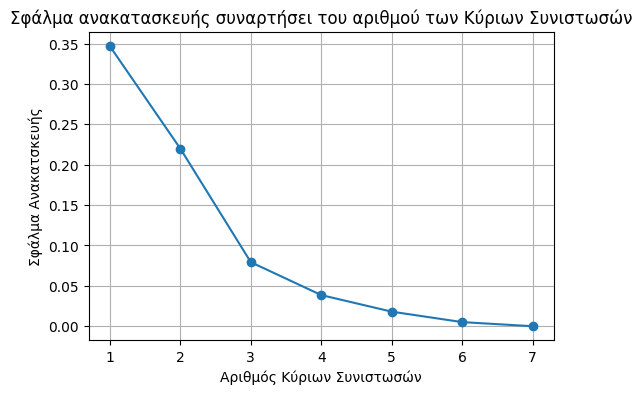



Το σφάλμα ανακατασκευής για 1 κύριες συνιστώσες είναι 34.67%
Το σφάλμα ανακατασκευής για 2 κύριες συνιστώσες είναι 21.99%
Το σφάλμα ανακατασκευής για 3 κύριες συνιστώσες είναι 7.93%
Το σφάλμα ανακατασκευής για 4 κύριες συνιστώσες είναι 3.86%
Το σφάλμα ανακατασκευής για 5 κύριες συνιστώσες είναι 1.8%
Το σφάλμα ανακατασκευής για 6 κύριες συνιστώσες είναι 0.51%
Το σφάλμα ανακατασκευής για 7 κύριες συνιστώσες είναι 0.0%


In [20]:
# Πίνακας με το σφάλμα ανακατασκευής για κάθε αριθμό κύριων συνιστωσών
reconstruction_errors = []

for n_components in range(1, 8):
    # Εφαρμογή PCA με n αριθμό κύριων συνιστωσών
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(features)
    reconstructed = pca.inverse_transform(principal_components)

    # Υπολογισμός σφάλματος ανακατασκευής
    error = np.mean(np.sqrt((features - reconstructed) ** 2))
    reconstruction_errors.append(error)

# Τύπωση διαγράμματος του σφάλματος ανακατασκευής
plt.figure(figsize=(6, 4))
plt.plot(range(1, 8), reconstruction_errors, marker='o')
plt.title('Σφάλμα ανακατασκευής συναρτήσει του αριθμού των Κύριων Συνιστωσών')
plt.xlabel('Αριθμός Κύριων Συνιστωσών')
plt.ylabel('Σφάλμα Ανακατσκευής')
plt.xticks(range(1, 8))
plt.grid(True)
plt.show()

print('\n')
for i in range(len(reconstruction_errors)):
  print(f"Το σφάλμα ανακατασκευής για {i+1} κύριες συνιστώσες είναι {round(100*reconstruction_errors[i], 2)}%")

Αρχικά αρχικοποιώ μια κενή λίστα όπου θα εισάγω τις τιμές του σφάλματος ανακατασκευής για κάθε αριθμό κύριων συνιστωσών.

Ορίζεται στη συνέχεια επαναληπτική διαδικασία για 1 έως και 7 συνιστώσες. Εντός του βρόχου αρχικά εφαρμόζεται η μέθοδος PCA για n_components κύριες συνιστώσες (στην 1η επανάληψη θα είναι για μία κύρια συνιστώσα, στην 2η για 2, κλπ). Τα κανονικοποιημένα, πλέον, δεδομένα μετασχηματίζονται στον χώρο που ορίζουν οι κύριες συνιστώσες με την χρήση της συνάρτησης fit_transform.

Στην συνέχεια με την συνάρτηση inverse_transform τα δεδομένα ανακατασκευάζονται στον αρχικό χώρο μέσω της inverse_transform.

Το σφάλμα υπολογίζεται στην συνέχεια ως  η μέση τιμή των ευκλείδειων διαφορών των αρχικών δεδομένων από τα ανακατασκευασμένα για κάθε επανάληψη (για κάθε διαφορετικό αριθμό κύριων συνιστωσών). Τα σφάλμα που υπολογίζεται σε κάθε επανάληψη τοποθετείται στην λίστα που ορίστηκε στην αρχή του cell.

Στο τέλος τυπώνονται τα αποτελέσματα σε ένα διάγραμμα. Στην ουσία είναι η γραφική παράσταση του σφάλματος ανακατασκευής συναρτήσει του αριθμού των κύριων συνιστωσών. Τα σφάλματα ανακατασκευής τυπώνονται και σε μορφή κειμένου αμέσως μετά το διάγραμμα.

# Ερώτημα Γ

Να εφαρμοστεί η μέθοδος LDA για την απεικόνιση του dataset σε 2 διαστάσεις. Να συγκρίνετε την απεικόνιση αυτή με την αντίστοιχη που παράγεται από τη μέθοδο PCA. Ποια τα κυριότερα ποιοτικά χαρακτηριστικά των απεικονίσεων που παράγουν οι δύο μέθοδοι και σε τι οφείλονται? Εξηγήστε

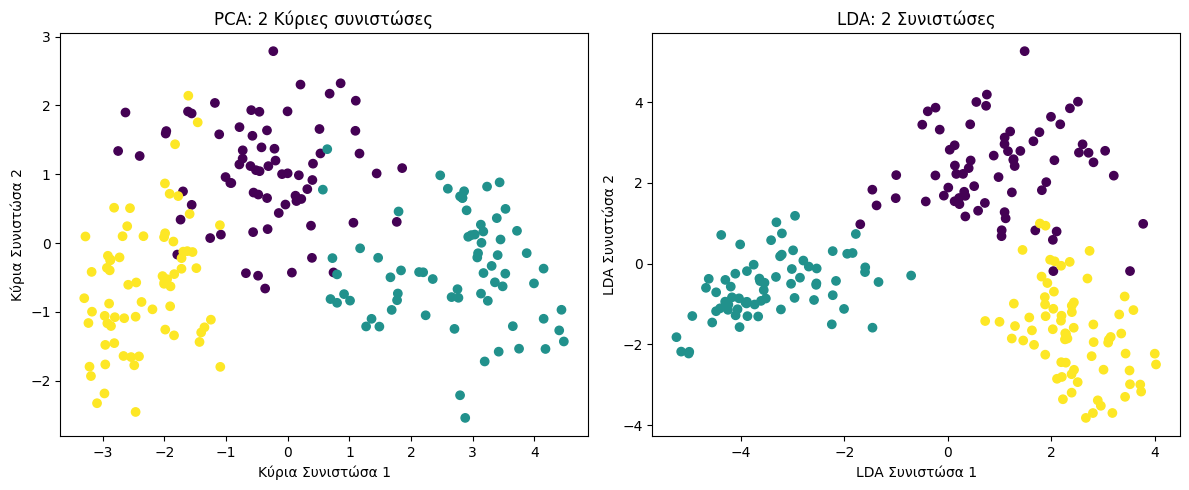

In [21]:
# Εφαρμογή LDA για 2 συνιστώσες
lda = LDA(n_components=2)
lda_components = lda.fit_transform(features, labels)

# Εφαρμογή PCA για 2 συνιστώσες
pca = PCA(n_components=2)
pca_components = pca.fit_transform(features)

# Δημιουργία διαγραμμάτων για PCA και LDA προβολές
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# PCA διάγραμμα
ax[0].scatter(pca_components[:, 0], pca_components[:, 1], c=labels)
ax[0].set_title('PCA: 2 Κύριες συνιστώσες')
ax[0].set_xlabel('Κύρια Συνιστώσα 1')
ax[0].set_ylabel('Κύρια Συνιστώσα 2')

# LDA διάγραμμα
ax[1].scatter(lda_components[:, 0], lda_components[:, 1], c=labels)
ax[1].set_title('LDA: 2 Συνιστώσες')
ax[1].set_xlabel('LDA Συνιστώσα 1')
ax[1].set_ylabel('LDA Συνιστώσα 2')

plt.tight_layout()
plt.show()

Αρχικά ορίζω αντικείμενο τύπου LDA το οποίο θα εφαρμόσει την LDA μόνο για 2 συνιστώσες και μεταφέρει με την επόμενη εντολή τα δεδομένα στον χώρο των 2 πρώτων συνιστωσών που υπολογίζονται από την LDA.

Ακριβώς με τον ίδιο τρόπο εργάζομαι και για την PCA (ορίζω αντικείμενο και μεταφέρω τα δεδομένα στον χώρο που ορίζουν οι πρώτες 2 κύριες συνιστώσες της PCA).

Στην συνέχεια ορίζω 2 διαγράμματα για να απεικονείσω τα δεδομένα στους 2 νέους χώρους που ορίζουν οι 2 πρώτες συνιστώσες για κάθε ανάλυση. Όπως πάντα τα δεδομένα τα χρωματίζω ανά κλάση (χρησιμοποιώ τον πίνακα labels που περιέχει τις ετικέτες των δεδομένων) για να δω ποσο καλά διαχωρίζονται τα δεδομένα στον νέο δισδιαστατο χώρο στον οποίο μετασχηματίζει καθε αναλυση τα δεδομένα.

# Ερώτημα Δ

Με βάση τον πίνακα προβολής που παράγεται από την LDA στο προηγούμενο ερώτημα, ποια είναι τα δύο χαρακτηριστικά (features) που συνεισφέρουν περισσότερο στη διάκριση μεταξύ των κλάσεων και ποια τα δύο που συνεισφέρουν λιγότερο απ’ όλα? Δημιουργείστε δυο δυσδιάστατες απεικονίσεις των δεδομένων χρησιμοποιώντας το καθένα από τα δύο ζεύγη χαρακτηριστικών που καταδείξατε. Σχολιάστε.

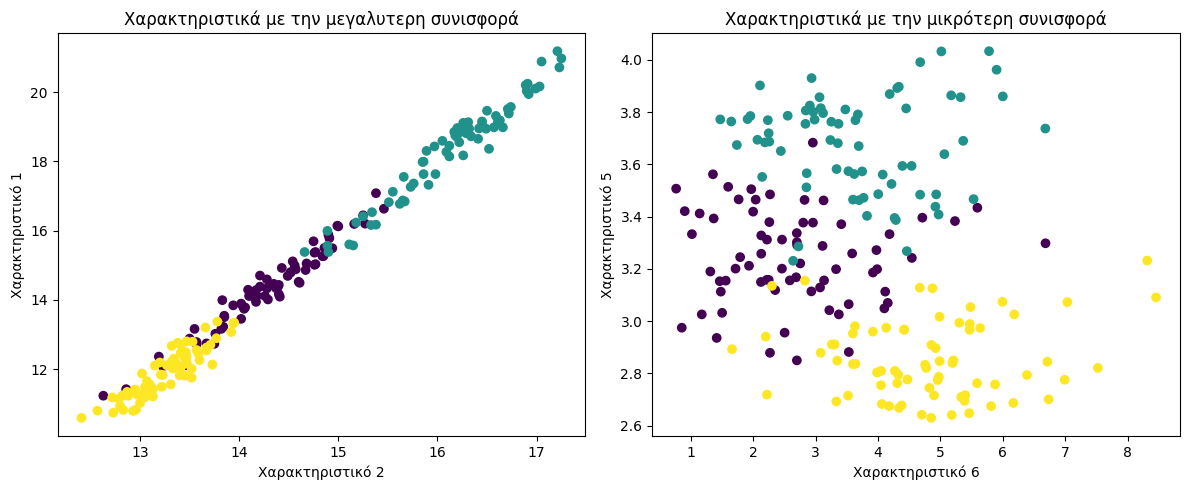


Οι συντελεστές του πίνακα προβολής μετα την εφαρμογή της μεθόδου LDA από τον οποίο προσδιορίζονται τα χαρακτηριστικά που συνισφέρουν περισσότερο στην διακύμανση μεταξύ των κλάσεων:
 [[-26.87071006  20.74171923   4.58955564  10.53948825  -0.63358234
   -1.04494663  -9.29231347]
 [  2.86031859  10.43134358  -0.71089924 -11.00940711   0.2031982
    0.04888467   7.1637587 ]
 [ 24.01039146 -31.17306281  -3.87865641   0.46991885   0.43038414
    0.99606196   2.12855477]]


Τα χαρακτηριστικά με την μεγαλύτερη συνισφορά (με φθίνουσα σειρά) είναι τα χαρακτηριστικά 2 και 1
Τα χαρακτηριστικά με την μικρότερη συνισφορά (με φθίνουσα σειρά) είναι τα χαρακτηριστικά 6 και 5

Γενικά η πλήρης σειρά συνισφοράς δίνεται στην ακόλουθη λίστα: [2 1 4 7 3 6 5]


In [22]:
# Παίρνω τις απόλυτες τιμές των συντελεστών των LDA συνιστωσών
lda_coefficients = np.abs(lda.coef_)

# Υπολογίζω την μέση τιμή των συντελεστών των LDA συνιστωσών
avg_coefficients = np.mean(lda_coefficients, axis=0)

# Ταξινόμηση των χαρακτηριστικών κατα φθίνουσα σειρα με βάση την συνισφορά τους στην διάκριση
sorted_features = np.argsort(avg_coefficients)[::-1]

# Τα 2 χαρακτηριστικά με την μεγαλύτερη συνισφορά στην διάκριση
most_contributing_features = sorted_features[:2]

# Τα 2 χαρακτηριστικά με την μικρότερη συνισφορά
least_contributing_features = sorted_features[-2:]

# Δημιουργία 2 ξεχωριστών 2D απεικονίσεων με διαφορετικό χρωματισμό για τις
# κλάσεις για τα χαρακτηριστικά με την μεγαλύτερη συνισφορά και με την μικρότερη
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Δημιουργία απεικόνισης για τα χαρακτηριστικά με την μεγαλύτερη συνισφορά
ax[0].scatter(data[:, most_contributing_features[0]], data[:, most_contributing_features[1]], c=labels)
ax[0].set_title('Χαρακτηριστικά με την μεγαλυτερη συνισφορά')
ax[0].set_xlabel(f'Χαρακτηριστικό {most_contributing_features[0] + 1}')
ax[0].set_ylabel(f'Χαρακτηριστικό {most_contributing_features[1] + 1}')

# Δημιουργία απεικόνισης για τα χαρακτηριστικά με την μικρότερη συνισφορά
ax[1].scatter(data[:, least_contributing_features[0]], data[:, least_contributing_features[1]], c=labels)
ax[1].set_title('Χαρακτηριστικά με την μικρότερη συνισφορά')
ax[1].set_xlabel(f'Χαρακτηριστικό {least_contributing_features[0] + 1}')
ax[1].set_ylabel(f'Χαρακτηριστικό {least_contributing_features[1] + 1}')

plt.tight_layout()
plt.show()

print(f'\nΟι συντελεστές του πίνακα προβολής μετα την εφαρμογή της μεθόδου LDA από τον οποίο προσδιορίζονται τα χαρακτηριστικά που συνισφέρουν περισσότερο στην διακύμανση μεταξύ των κλάσεων:\n', lda.coef_)

print(f'\n\nΤα χαρακτηριστικά με την μεγαλύτερη συνισφορά (με φθίνουσα σειρά) είναι τα χαρακτηριστικά {most_contributing_features[0]+1} και {most_contributing_features[1]+1}')
print(f'Τα χαρακτηριστικά με την μικρότερη συνισφορά (με φθίνουσα σειρά) είναι τα χαρακτηριστικά {least_contributing_features[0]+1} και {least_contributing_features[1]+1}')

print("\nΓενικά η πλήρης σειρά συνισφοράς δίνεται στην ακόλουθη λίστα:", sorted_features+1)

Αρχικά υπολογίζονται οι απόλυτες τιμές των συντελεστών κάθε συνιστώσας της LDA, οι οποίες αντιστοιχούν στις γραμμές του διανύσματος προβολής και χρησιμοποιούνται για την διάκριση μεταξύ των κλάσεων.

Στην συνέχεια παίρνω τις μέσες τιμές για κάθε στήλη των συντελεστών από τις 7 συνιστώσες. Αυτό μας επιστρέφει μία εκτίμηση της συνισφοράς κάθε συνιστώσας στην διάκριση.

Αμέσως μετά ταξινομούμε τις συνιστώσες με βάση την συνισφορά τους με φθίνουσα σειρα (εξού και [::-1]). Ο τρόπος που συμβολίζεται η συνιστώσα στην ταξινόμηση είναι το index της για να ξέρουμε ποια συνιστώσα θα καλούμε στην συνέχεια για την απεικόνιση των διαγραμμάτων. Ακόμη επειδή η αρίθμηση των index ξεκινάει από την τιμή 0 σην απεικόνιση και στις τυπώσεις προσθέτω 1 για να γίνει και οι αντισοίχιση για εμάς στα δεδομένα.

Στην συνέχεια κρατάω στην μεταβλητή most_contributing_features τις 2 πρώτες συνιστώσες από την λιστα που τις έχει ταξινομημένες με βάσει την συνισφορά τους. Ακριβώς πάνω στην ίδια λογική στην μεταβλητή least_contributing_features κρατάω σε μία λίστα τις δύο τελευταίες συνιστώσες από την ταξινομημένη λίστα της sorted_features.

Τέλος για τις δύο απεικονίσεις γίνονται 2 διαγράμματα και σε κάθε άξονα μπαίνει μία συνιστώσα και με βάση την τιμή των δεδομένων στις δύο συνιστώσες (για κάθε διάγραμμα) αποτυπώνωνται ως τελείες στον χώρο τα ίδια τα δεδομένα.

Στην αρίστερή απεικόνιση αποτυπώνονται συναρτήσει των συνιστωσών που συνισφέρουν περισσότερο και στην δεξιά συναρτήσει αυτών που συνισφέρουν λιγότερο.